In [ ]:
import os
import glob

for root, dirs, files in os.walk("/kaggle/input"):
    pngs = glob.glob(os.path.join(root, "*.png"))
    if pngs:
        print(root, len(pngs))
        print(pngs[:5])

In [ ]:
import glob
import os

KODAK_DIR = "/kaggle/input/datasets/drxinchengzhu/kodak24/images/train"

img_paths = sorted(glob.glob(os.path.join(KODAK_DIR, "*.png")))
print("num images:", len(img_paths))
print(img_paths[:5])

assert len(img_paths) == 24, f"Expected 24 images, found {len(img_paths)}"

In [ ]:
%pip install -q compressai scikit-image

In [ ]:
import sys
print(sys.executable)

import compressai
print("compressai version:", compressai.__version__)

In [1]:
import sys
print(sys.executable)

import compressai
print("compressai version:", compressai.__version__)

/usr/bin/python3
compressai version: 1.2.8


In [3]:
import os
import glob
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from skimage.metrics import structural_similarity as ssim_metric

import torch
import torch.nn.functional as F
from torchvision import transforms

from compressai.zoo import (
    bmshj2018_factorized,
    bmshj2018_hyperprior,
    mbt2018,
    mbt2018_mean,
)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cpu


In [4]:
to_tensor = transforms.ToTensor()

def load_image(path):
    img = Image.open(path).convert("RGB")
    x = to_tensor(img).unsqueeze(0)
    return x.to(device), img

In [5]:
def compute_psnr(x, x_hat):
    mse = F.mse_loss(x_hat, x).item()
    if mse == 0:
        return float("inf")
    return -10.0 * math.log10(mse)

def compute_ssim(x, x_hat):
    x_np = x.squeeze(0).detach().cpu().permute(1, 2, 0).numpy()
    xh_np = x_hat.squeeze(0).detach().cpu().permute(1, 2, 0).numpy()
    return ssim_metric(x_np, xh_np, channel_axis=2, data_range=1.0)

def compute_bpp_from_likelihoods(out, num_pixels):
    bpp = 0.0
    for likelihoods in out["likelihoods"].values():
        bpp += torch.log(likelihoods).sum() / (-math.log(2) * num_pixels)
    return bpp

def compute_bpp_from_bitstreams(strings, num_pixels):
    total_bits = 0
    for s_group in strings:
        for s in s_group:
            total_bits += len(s) * 8
    return total_bits / num_pixels

In [6]:
@torch.no_grad()
def evaluate_one_image(model, x):
    model.eval()
    num_pixels = x.size(0) * x.size(2) * x.size(3)

    out = model(x)
    bpp_est = compute_bpp_from_likelihoods(out, num_pixels).item()

    enc = model.compress(x)
    dec = model.decompress(enc["strings"], enc["shape"])
    x_hat_real = dec["x_hat"].clamp(0, 1)
    bpp_real = compute_bpp_from_bitstreams(enc["strings"], num_pixels)

    psnr = compute_psnr(x, x_hat_real)
    ssim = compute_ssim(x, x_hat_real)

    return {
        "x_hat": x_hat_real,
        "bpp_est": bpp_est,
        "bpp_real": bpp_real,
        "psnr": psnr,
        "ssim": ssim,
    }

In [7]:
def get_model(arch, quality):
    if arch == "bmshj2018-factorized":
        model = bmshj2018_factorized(quality=quality, pretrained=True)
    elif arch == "bmshj2018-hyperprior":
        model = bmshj2018_hyperprior(quality=quality, pretrained=True)
    elif arch == "mbt2018":
        model = mbt2018(quality=quality, pretrained=True)
    elif arch == "mbt2018-mean":
        model = mbt2018_mean(quality=quality, pretrained=True)
    else:
        raise ValueError(f"Unknown architecture: {arch}")
    return model.to(device).eval()

In [8]:
def evaluate_dataset(arch="bmshj2018-factorized", qualities=(1, 2, 3, 4, 5, 6, 7, 8)):
    rows = []
    for q in qualities:
        print(f"Evaluating quality {q}...")
        model = get_model(arch, q)
        for path in img_paths:
            x, _ = load_image(path)
            res = evaluate_one_image(model, x)
            rows.append({
                "arch": arch,
                "quality": q,
                "image": os.path.basename(path),
                "bpp_est": res["bpp_est"],
                "bpp_real": res["bpp_real"],
                "psnr": res["psnr"],
                "ssim": res["ssim"],
            })
    return pd.DataFrame(rows)

In [10]:
KODAK_DIR = "/kaggle/input/datasets/drxinchengzhu/kodak24/images/train"
img_paths = sorted(glob.glob(os.path.join(KODAK_DIR, "*.png")))

In [12]:
df = evaluate_dataset("bmshj2018-factorized", qualities=[1, 2, 3, 4, 5, 6, 7, 8])
df.head()

Evaluating quality 1...
Evaluating quality 2...
Evaluating quality 3...
Evaluating quality 4...
Evaluating quality 5...
Evaluating quality 6...
Evaluating quality 7...
Evaluating quality 8...


,arch,quality,image,bpp_est,bpp_real,psnr,ssim
0,bmshj2018-factorized,1,kodim01.png,0.164348,0.164632,24.743168,0.643294
1,bmshj2018-factorized,1,kodim02.png,0.101613,0.101807,28.583170,0.712696
2,bmshj2018-factorized,1,kodim03.png,0.090541,0.090739,30.146858,0.818847
3,bmshj2018-factorized,1,kodim04.png,0.100216,0.100423,28.616203,0.730458
4,bmshj2018-factorized,1,kodim05.png,0.186952,0.187256,23.542935,0.677220


In [13]:
rd = df.groupby(["arch", "quality"], as_index=False).agg({
    "bpp_real": "mean",
    "bpp_est": "mean",
    "psnr": "mean",
    "ssim": "mean",
})
rd

,arch,quality,bpp_real,bpp_est,psnr,ssim
0,bmshj2018-factorized,1,0.122623,0.122387,26.908787,0.725434
1,bmshj2018-factorized,2,0.188527,0.188215,28.217926,0.776435
2,bmshj2018-factorized,3,0.287808,0.287326,29.616907,0.824908
3,bmshj2018-factorized,4,0.440375,0.439708,31.277080,0.871288
4,bmshj2018-factorized,5,0.648139,0.647169,32.956130,0.907208
5,bmshj2018-factorized,6,0.966977,0.965329,35.380941,0.938428
6,bmshj2018-factorized,7,1.351159,1.349253,37.396929,0.957597
7,bmshj2018-factorized,8,1.833272,1.830454,39.621307,0.971301


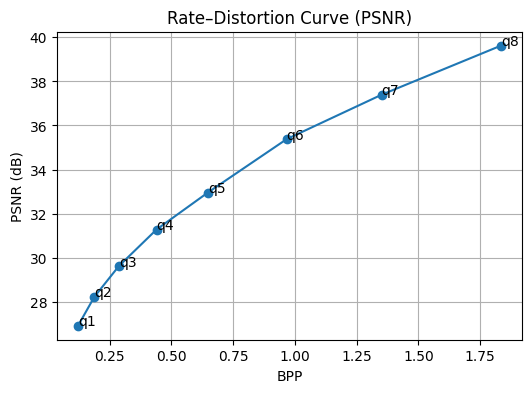

In [14]:
plt.figure(figsize=(6, 4))
plt.plot(rd["bpp_real"], rd["psnr"], marker="o")
for _, row in rd.iterrows():
    plt.annotate(f"q{int(row['quality'])}", (row["bpp_real"], row["psnr"]))
plt.xlabel("BPP")
plt.ylabel("PSNR (dB)")
plt.title("Rate–Distortion Curve (PSNR)")
plt.grid(True)
plt.show()

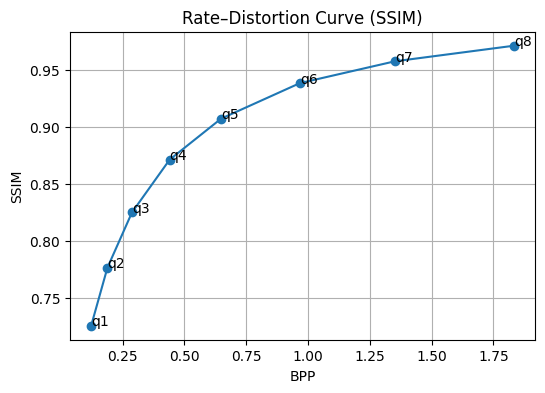

In [15]:
plt.figure(figsize=(6, 4))
plt.plot(rd["bpp_real"], rd["ssim"], marker="o")
for _, row in rd.iterrows():
    plt.annotate(f"q{int(row['quality'])}", (row["bpp_real"], row["ssim"]))
plt.xlabel("BPP")
plt.ylabel("SSIM")
plt.title("Rate–Distortion Curve (SSIM)")
plt.grid(True)
plt.show()

In [34]:
def evaluate_attacks_on_subset(
    model_arch="bmshj2018-factorized",
    quality=3,
    image_indices=(0, 1, 2, 3, 4),
    eps=8/255,
    step_size=1/255,
    steps=30,
):
    rows = []

    for idx in image_indices:
        print(f"Processing image index {idx}...")
        model = get_model(model_arch, quality)
        x_clean_i, _ = load_image(img_paths[idx])

        model.eval()
        _, x_hat_clean_i, clean_rate_est_i = forward_with_rate(model, x_clean_i)
        clean_bpp_real_i = actual_bpp_via_bitstream(model, x_clean_i)

        x_adv_d_i, x_hat_adv_d_i, _, rate_d_i = run_attack(
            model,
            x_clean_i,
            objective="distortion",
            eps=eps,
            step_size=step_size,
            steps=steps,
            lam_rate=0.0,
            lam_input=0.01,
            random_start=True,
        )
        adv_d_bpp_real_i = actual_bpp_via_bitstream(model, x_adv_d_i)

        x_adv_r_i, x_hat_adv_r_i, _, rate_r_i = run_attack(
            model,
            x_clean_i,
            objective="bitrate",
            eps=eps,
            step_size=step_size,
            steps=steps,
            lam_dist=0.0,
            lam_input=0.01,
            random_start=True,
        )
        adv_r_bpp_real_i = actual_bpp_via_bitstream(model, x_adv_r_i)

        rows.extend([
            {
                "image_idx": idx,
                "case": "clean",
                "psnr": compute_psnr(x_clean_i, x_hat_clean_i),
                "ssim": compute_ssim(x_clean_i, x_hat_clean_i),
                "bpp_est": clean_rate_est_i.item(),
                "bpp_real": clean_bpp_real_i,
            },
            {
                "image_idx": idx,
                "case": "max_distortion_attack",
                "psnr": compute_psnr(x_clean_i, x_hat_adv_d_i),
                "ssim": compute_ssim(x_clean_i, x_hat_adv_d_i),
                "bpp_est": rate_d_i,
                "bpp_real": adv_d_bpp_real_i,
            },
            {
                "image_idx": idx,
                "case": "max_bitrate_attack",
                "psnr": compute_psnr(x_clean_i, x_hat_adv_r_i),
                "ssim": compute_ssim(x_clean_i, x_hat_adv_r_i),
                "bpp_est": rate_r_i,
                "bpp_real": adv_r_bpp_real_i,
            },
        ])

    return pd.DataFrame(rows)

In [35]:
attack_df = evaluate_attacks_on_subset(
    model_arch="bmshj2018-factorized",
    quality=3,
    image_indices=(0, 1, 2, 3, 4),
    eps=8/255,
    step_size=1/255,
    steps=30,
)

attack_df.head()

Processing image index 0...
Processing image index 1...
Processing image index 2...
Processing image index 3...
Processing image index 4...


,image_idx,case,psnr,ssim,bpp_est,bpp_real
0,0,clean,27.030660,0.774940,0.398244,0.398926
1,0,max_distortion_attack,24.370889,0.693384,0.402988,0.387858
2,0,max_bitrate_attack,26.494548,0.787100,0.587367,0.610840
3,1,clean,31.305025,0.784620,0.222091,0.222331
4,1,max_distortion_attack,27.260834,0.712919,0.242787,0.208496


In [36]:
attack_summary = attack_df.groupby("case", as_index=False).agg({
    "psnr": "mean",
    "ssim": "mean",
    "bpp_est": "mean",
    "bpp_real": "mean",
})

attack_summary

,case,psnr,ssim,bpp_est,bpp_real
0,clean,29.785817,0.815627,0.299656,0.300130
1,max_bitrate_attack,28.773158,0.799333,0.480847,0.488184
2,max_distortion_attack,26.172402,0.739153,0.310127,0.285319


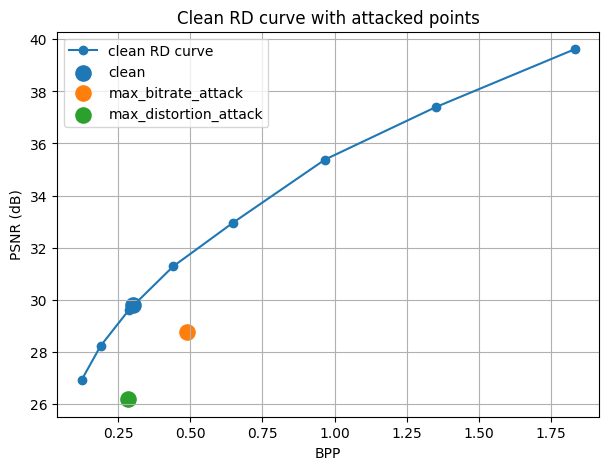

In [38]:
plt.figure(figsize=(7, 5))

# clean RD curve from earlier dataset evaluation
plt.plot(rd["bpp_real"], rd["psnr"], marker="o", label="clean RD curve")

# average attacked points
for _, row in attack_summary.iterrows():
    plt.scatter(row["bpp_real"], row["psnr"], s=120, label=row["case"])

plt.xlabel("BPP")
plt.ylabel("PSNR (dB)")
plt.title("Clean RD curve with attacked points")
plt.grid(True)
plt.legend()
plt.show()

In [39]:
arch_results = []
for arch in ["bmshj2018-factorized", "bmshj2018-hyperprior", "mbt2018"]:
    print("Evaluating", arch)
    df_arch = evaluate_dataset(arch=arch, qualities=[1, 3, 5, 8])
    arch_results.append(df_arch)

arch_df = pd.concat(arch_results, ignore_index=True)

arch_rd = arch_df.groupby(["arch", "quality"], as_index=False).agg({
    "bpp_real": "mean",
    "psnr": "mean",
})

arch_rd

Evaluating bmshj2018-factorized
Evaluating quality 1...
Evaluating quality 3...
Evaluating quality 5...
Evaluating quality 8...
Evaluating bmshj2018-hyperprior
Evaluating quality 1...
Downloading: "https://compressai.s3.amazonaws.com/models/v1/bmshj2018-hyperprior-1-7eb97409.pth.tar" to /root/.cache/torch/hub/checkpoints/bmshj2018-hyperprior-1-7eb97409.pth.tar


100%|██████████| 20.2M/20.2M [00:01<00:00, 11.0MB/s]


Evaluating quality 3...
Downloading: "https://compressai.s3.amazonaws.com/models/v1/bmshj2018-hyperprior-3-6d87be32.pth.tar" to /root/.cache/torch/hub/checkpoints/bmshj2018-hyperprior-3-6d87be32.pth.tar


100%|██████████| 20.2M/20.2M [00:02<00:00, 9.61MB/s]


Evaluating quality 5...
Downloading: "https://compressai.s3.amazonaws.com/models/v1/bmshj2018-hyperprior-5-f8b614e1.pth.tar" to /root/.cache/torch/hub/checkpoints/bmshj2018-hyperprior-5-f8b614e1.pth.tar


...

Evaluating quality 5...
Downloading: "https://compressai.s3.amazonaws.com/models/v1/mbt2018-5-b4a046dd.pth.tar" to /root/.cache/torch/hub/checkpoints/mbt2018-5-b4a046dd.pth.tar


100%|██████████| 118M/118M [00:07<00:00, 15.7MB/s] 


Evaluating quality 8...
Downloading: "https://compressai.s3.amazonaws.com/models/v1/mbt2018-8-dd0097aa.pth.tar" to /root/.cache/torch/hub/checkpoints/mbt2018-8-dd0097aa.pth.tar


100%|██████████| 118M/118M [00:09<00:00, 13.2MB/s] 


,arch,quality,bpp_real,psnr
0,bmshj2018-factorized,1,0.122623,26.908787
1,bmshj2018-factorized,3,0.287808,29.616907
2,bmshj2018-factorized,5,0.648139,32.956130
3,bmshj2018-factorized,8,1.833272,39.621307
4,bmshj2018-hyperprior,1,0.131293,27.581537
5,bmshj2018-hyperprior,3,0.319858,30.972172
6,bmshj2018-hyperprior,5,0.668688,34.526261
7,bmshj2018-hyperprior,8,1.660227,40.556871
8,mbt2018,1,0.110535,28.088536
9,mbt2018,3,0.287703,31.362356


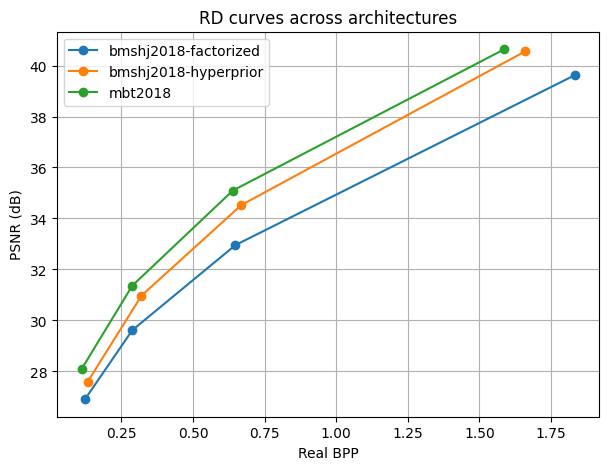

In [40]:
plt.figure(figsize=(7, 5))
for arch, grp in arch_rd.groupby("arch"):
    plt.plot(grp["bpp_real"], grp["psnr"], marker="o", label=arch)

plt.xlabel("Real BPP")
plt.ylabel("PSNR (dB)")
plt.title("RD curves across architectures")
plt.grid(True)
plt.legend()
plt.show()

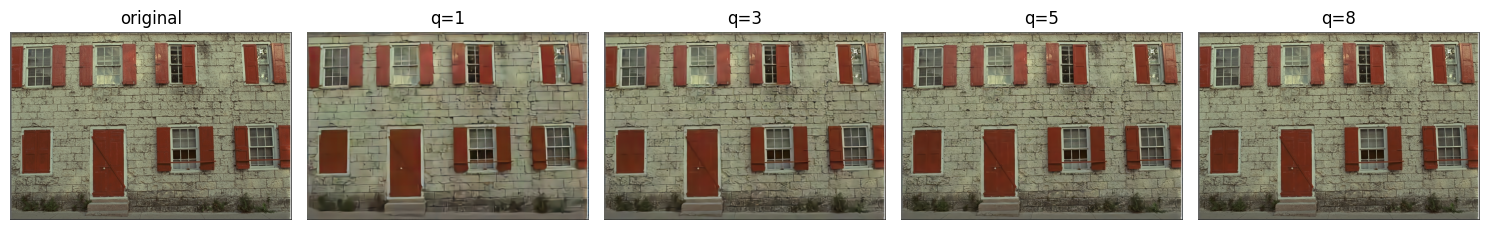

In [41]:
x_vis, _ = load_image(img_paths[0])

qualities_to_show = [1, 3, 5, 8]

plt.figure(figsize=(15, 4))

# original
orig = x_vis.squeeze(0).detach().cpu().permute(1, 2, 0).numpy()
plt.subplot(1, len(qualities_to_show) + 1, 1)
plt.imshow(orig)
plt.title("original")
plt.axis("off")

for i, q in enumerate(qualities_to_show, start=2):
    model_q = get_model("bmshj2018-factorized", q)
    model_q.eval()
    with torch.no_grad():
        out_q = model_q(x_vis)
        x_hat_q = out_q["x_hat"].clamp(0, 1)
    arr_q = x_hat_q.squeeze(0).detach().cpu().permute(1, 2, 0).numpy()

    plt.subplot(1, len(qualities_to_show) + 1, i)
    plt.imshow(arr_q)
    plt.title(f"q={q}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [44]:
import os

print(os.getcwd())
print(os.listdir("/kaggle/working"))

/kaggle/working
['architecture_rd_results.csv', '.virtual_documents', 'attack_subset_results.csv', 'attack_summary.csv', 'rd_curve_results.csv']


In [46]:
if "must_have_results" in globals():
    must_have_results.to_csv("must_have_results.csv", index=False)
    print("Saved: must_have_results.csv")

if "attack_df" in globals():
    attack_df.to_csv("attack_subset_results.csv", index=False)
    print("Saved: attack_subset_results.csv")

if "attack_summary" in globals():
    attack_summary.to_csv("attack_summary.csv", index=False)
    print("Saved: attack_summary.csv")

if "rd" in globals():
    rd.to_csv("rd_curve_results.csv", index=False)
    print("Saved: rd_curve_results.csv")

if "arch_rd" in globals():
    arch_rd.to_csv("architecture_rd_results.csv", index=False)
    print("Saved: architecture_rd_results.csv")

Saved: attack_subset_results.csv
Saved: attack_summary.csv
Saved: rd_curve_results.csv
Saved: architecture_rd_results.csv
